In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models
import glob
import hashlib
from tqdm import tqdm
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error

## Constants

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBEDDING_CACHE_DIR = Path("embeddings") # For caching image embeddings
EMBEDDING_CACHE_DIR.mkdir(exist_ok=True)
CSV_PATH = Path("experiments/experiments_1_36.csv")
TOP_FOLDER = Path("photos/100OLYMP_Top_0502")
SIDE_FOLDER = Path("photos/100OLYMP_side_0502")

## Data Loading

In [3]:
data = pd.read_csv(CSV_PATH)

samples = data.copy()
samples = samples[samples["volume"] > 0]
samples = samples[samples["pic_top"].notna() & samples["pic_side"].notna()]

samples["exp_id"] = samples["exp_id"].astype(int)
samples["pic_top"] = samples["pic_top"].astype(int)
samples["pic_side"] = samples["pic_side"].astype(int)

print("Samples:", len(samples))
display(samples.head())

Samples: 140


,file_name,bridge_angle,Fr,Fr_ini,plates,cubes,logs,Q[dm],H_up,H_down,...,H_down_corr,pic_side,pic_top,dh,dh_d0,rel_BW,carpet_length_avg,carpet_length_max,exp_id,volume
2,NaN,22.5,0.018605,0.55,0.25,0.00,0.75,18.6,142.5,14.10,...,87.0,161,72,49.5,0.550000,NaN,NaN,NaN,1,38
3,NaN,22.5,0.018605,0.55,0.25,0.00,0.75,18.6,145.5,14.10,...,87.0,163,73,52.5,0.583333,NaN,NaN,NaN,1,57
4,NaN,22.5,0.018605,0.55,0.25,0.00,0.75,18.6,148.0,14.00,...,86.0,167,74,56.0,0.622222,0.510638,73,86,1,76
6,dried debris,22.5,0.018605,0.55,0.00,0.25,0.75,18.6,106.0,14.30,...,89.0,171,75,11.0,0.122222,NaN,NaN,NaN,2,19
7,NaN,22.5,0.018605,0.55,0.00,0.25,0.75,18.6,138.0,14.15,...,87.5,173,76,44.5,0.494444,NaN,NaN,NaN,2,38


## Attaching Image Paths to the Samples

In [4]:
def find_photo(folder, pic_num):

    for ext in ["jpg","JPG","jpeg","JPEG","png","PNG"]:
        for padding in [3,4]:
            pattern = str(folder / f"*{pic_num:0{padding}d}.{ext}")
            matches = glob.glob(pattern)

            if matches:
                return matches[0]

    raise FileNotFoundError(f"No photo for {pic_num}")

In [5]:
samples["top_path"] = samples["pic_top"].apply(lambda x: find_photo(TOP_FOLDER, x))
samples["side_path"] = samples["pic_side"].apply(lambda x: find_photo(SIDE_FOLDER, x))
display(samples[["exp_id","volume","top_path","side_path"]].head())

,exp_id,volume,top_path,side_path
2,1,38,photos/100OLYMP_Top_0502/P2090072.JPG,photos/100OLYMP_side_0502/P2090161.JPG
3,1,57,photos/100OLYMP_Top_0502/P2090073.JPG,photos/100OLYMP_side_0502/P2090163.JPG
4,1,76,photos/100OLYMP_Top_0502/P2090074.JPG,photos/100OLYMP_side_0502/P2090167.JPG
6,2,19,photos/100OLYMP_Top_0502/P2090075.JPG,photos/100OLYMP_side_0502/P2090171.JPG
7,2,38,photos/100OLYMP_Top_0502/P2090076.JPG,photos/100OLYMP_side_0502/P2090173.JPG


## Feature-extraction Model Setup

In [6]:
weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
resnet = models.resnet50(weights=weights)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


## Embedding Computation

In [7]:
def embedding_cache_path(image_path):
    key = str(Path(image_path).resolve())
    h = hashlib.md5(key.encode()).hexdigest()
    return EMBEDDING_CACHE_DIR / f"{h}.npy"

@torch.no_grad()
def compute_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    x = preprocess(image).unsqueeze(0).to(DEVICE)
    feat = feature_extractor(x)
    feat = feat.flatten(1).cpu().numpy()[0]
    return feat.astype(np.float32)

def get_embedding(image_path):
    cache_file = embedding_cache_path(image_path)

    # If the embedding is already cached, use that
    if cache_file.exists():
        return np.load(cache_file)

    feat = compute_embedding(image_path)
    np.save(cache_file, feat)
    return feat

In [8]:
top_embeddings = []
side_embeddings = []

for _, row in tqdm(samples.iterrows(), total=len(samples)):
    top_vector = get_embedding(row["top_path"])
    side_vector = get_embedding(row["side_path"])
    top_embeddings.append(top_vector)
    side_embeddings.append(side_vector)

top_embeddings = np.vstack(top_embeddings)
side_embeddings = np.vstack(side_embeddings)

X = np.hstack([top_embeddings, side_embeddings])
y = samples["volume"].values

print("X shape:", X.shape)

100%|██████████| 140/140 [00:00<00:00, 2589.35it/s]

X shape: (140, 4096)


## Regression Models Setup

In [9]:
models_dict = {
    "dummy_mean": DummyRegressor(strategy="mean"),

    "linear_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),

    "ridge_alpha_1": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),

    "ridge_alpha_10": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),

    "elasticnet": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=20000)),
    ]),

    "random_forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),

    "extra_trees": ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

## Performance Evaluation with Cross-validation

In [10]:
# Using GroupKFold for cross-validation, grouping by experiment ID
# (So training and test data does not contain samples from the same experiment, that would be bad)
groups = samples["exp_id"].values
n_groups = len(np.unique(groups))
n_splits = min(5, n_groups)
group_folds = GroupKFold(n_splits=n_splits)

rows = []
for name, model in models_dict.items():
    cv_res = cross_validate(
        model, X, y,
        groups=groups,
        cv=group_folds,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    rows.append({
        "model": name,
        "cv_mae_mean": -cv_res["test_mae"].mean(),
        "cv_mae_std": cv_res["test_mae"].std(),
        "cv_mse_mean": -cv_res["test_mse"].mean(),
        "cv_mse_std": cv_res["test_mse"].std(),
        "cv_rmse_mean": -cv_res["test_rmse"].mean(),
        "cv_rmse_std": cv_res["test_rmse"].std(),
        "cv_r2_mean": cv_res["test_r2"].mean(),
        "cv_r2_std": cv_res["test_r2"].std(),
    })

results_df = pd.DataFrame(rows).sort_values("cv_mae_mean").reset_index(drop=True)
display(results_df)

,model,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,elasticnet,7.345940,0.599207,82.651255,13.672932,9.056063,0.799364,0.816625,0.030634
1,extra_trees,8.618006,0.824268,109.881477,18.416988,10.445135,0.883529,0.755962,0.042315
2,random_forest,8.859612,0.958818,113.433857,17.342883,10.619297,0.815094,0.748299,0.038810
3,ridge_alpha_10,17.767816,21.334677,16260.739767,32365.816185,63.944826,110.325878,-35.034903,71.724787
4,ridge_alpha_1,17.795819,21.383857,16339.432220,32523.091051,64.085211,110.600722,-35.209289,72.073316
5,linear_regression,17.798961,21.389375,16348.273202,32540.760404,64.100961,110.631543,-35.228880,72.112471
6,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


## Removing Unstable/Poor Models to Exclude from Further Analysis

In [11]:
okay_models = models_dict.copy()
okay_models.pop("ridge_alpha_1")
okay_models.pop("ridge_alpha_10")
okay_models.pop("linear_regression")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

## Out-of-fold Output Analysis

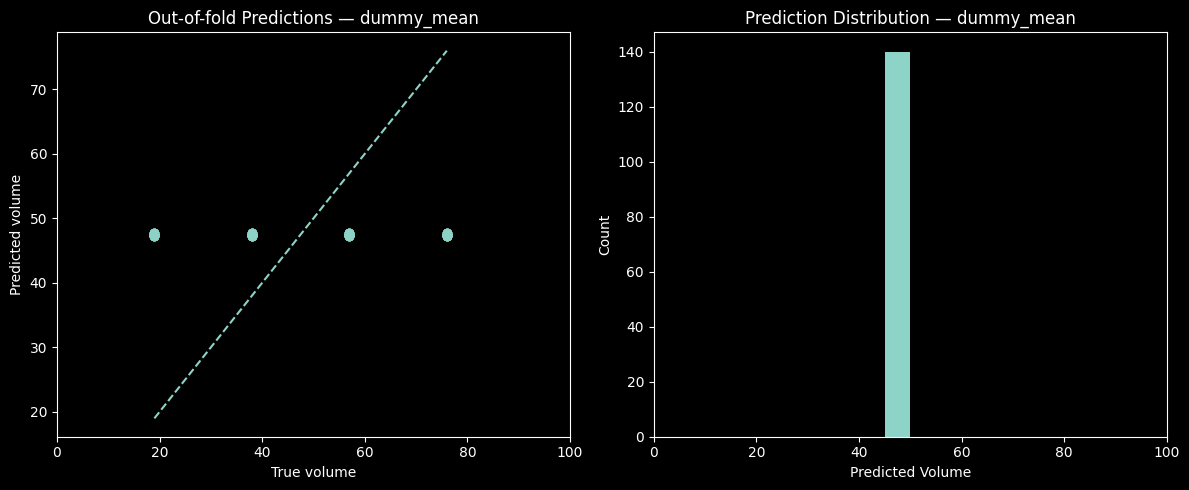

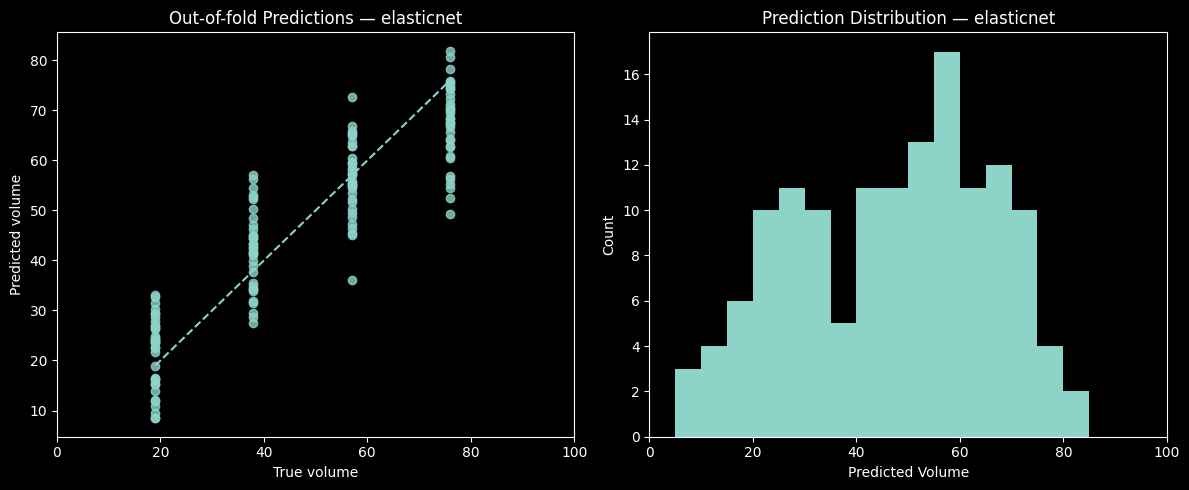

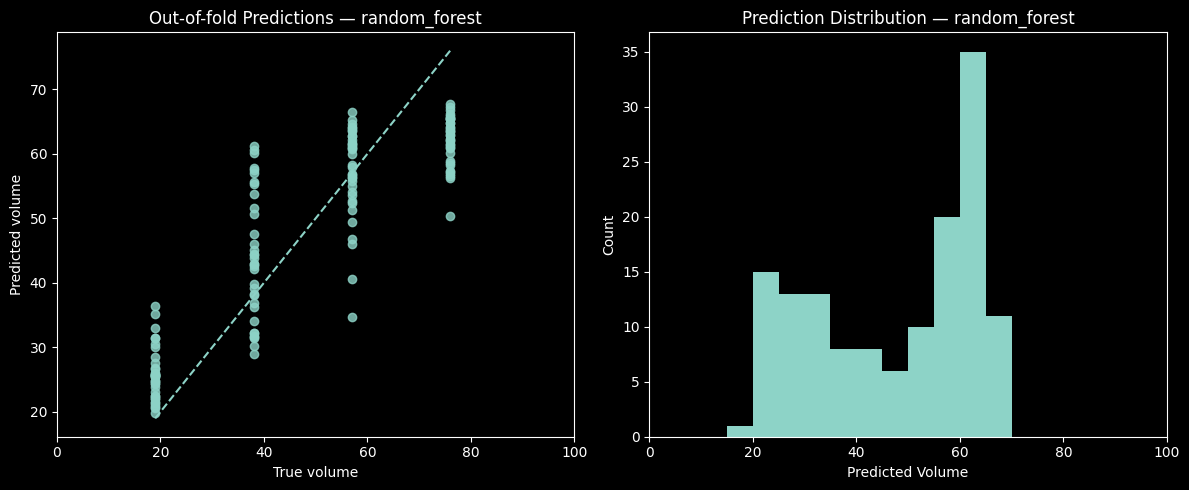

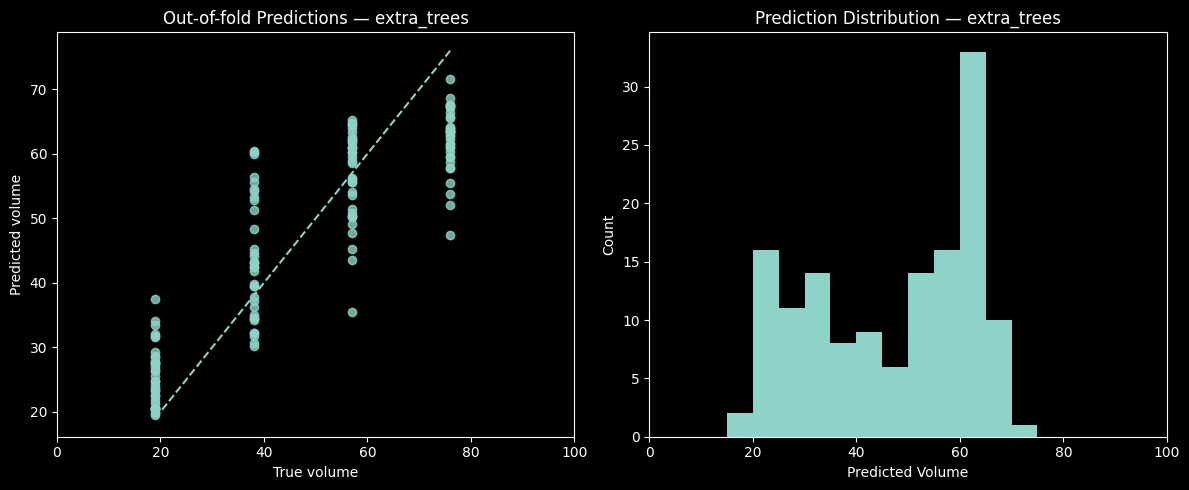

,model,mae,mse,rmse,r2
0,elasticnet,7.344615,82.528381,9.084514,0.817112
1,extra_trees,8.614992,109.723836,10.474915,0.756845
2,random_forest,8.872382,113.658775,10.661087,0.748125
3,dummy_mean,19.002402,451.431003,21.246906,-0.000401


In [18]:
# Out-of-fold = for each data point we calculate the predicted volume,
# using a model trained on the folds that did not contain that point

rows = []
for name, model in okay_models.items():
    pred = cross_val_predict(
        model, X, y,
        groups=groups,
        cv=group_folds,
        n_jobs=-1,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # True vs predicted volume
    axes[0].scatter(y, pred, alpha=0.8)
    axes[0].set_xlim(0, 100)
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    axes[0].set_xlabel("True volume")
    axes[0].set_ylabel("Predicted volume")
    axes[0].set_title(f"Out-of-fold Predictions — {name}")

    # Histogram of predictions
    axes[1].hist(pred, bins=20, range=(0, 100))
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Predicted Volume")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Prediction Distribution — {name}")

    plt.tight_layout()
    plt.show()

    rows.append({
        "model": name,
        "mae": mean_absolute_error(y, pred),
        "mse": mean_squared_error(y, pred),
        "rmse": root_mean_squared_error(y, pred),
        "r2": r2_score(y, pred),
    })

results_df = pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)
display(results_df)


## Leave-one-volume-out Cross-validation

In [19]:
# Leave-one-volume-out = we split the data based on the volume labels,
# then always train on all volume sizes except one, and evaluate on that one

unique_volumes = np.sort(np.unique(y))
fold_rows = []
all_predictions = []

for model_name, model in okay_models.items():
    for held_out_volume in unique_volumes:
        train_mask = y != held_out_volume
        test_mask = y == held_out_volume

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        groups_train = groups[train_mask]
        groups_test = groups[test_mask]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)

        fold_rows.append({
            "model": model_name,
            "held_out_volume": float(held_out_volume),
            "pred_mean": float(np.mean(y_pred)),
            "pred_std": float(np.std(y_pred)),
            "mae": mae,
            "mse": mse,
            "rmse": rmse,
            "n_train": len(y_train),
            "n_test": len(y_test)
        })

        fold_pred_df = pd.DataFrame({
            "model": model_name,
            "held_out_volume": held_out_volume,
            "exp_id": groups_test,
            "true_volume": y_test,
            "pred_volume": y_pred,
            "abs_error": np.abs(y_test - y_pred),
        })
        all_predictions.append(fold_pred_df)

leave_one_volume_results = pd.DataFrame(fold_rows)
leave_one_volume_predictions = pd.concat(all_predictions, ignore_index=True)

display(leave_one_volume_results)

,model,held_out_volume,pred_mean,pred_std,mae,mse,rmse,n_train,n_test
0,dummy_mean,19.0,57.000000,0.000000e+00,38.000000,1444.000000,38.000000,105,35
1,dummy_mean,38.0,50.666667,7.105427e-15,12.666667,160.444444,12.666667,105,35
2,dummy_mean,57.0,44.333333,7.105427e-15,12.666667,160.444444,12.666667,105,35
3,dummy_mean,76.0,38.000000,0.000000e+00,38.000000,1444.000000,38.000000,105,35
4,elasticnet,19.0,29.061832,7.380102e+00,10.984746,155.706360,12.478235,105,35
5,elasticnet,38.0,45.447437,7.977556e+00,8.810216,119.105751,10.913558,105,35
6,elasticnet,57.0,59.681927,8.973711e+00,6.714682,87.720238,9.365909,105,35
7,elasticnet,76.0,58.845325,4.935961e+00,17.154671,318.646454,17.850672,105,35
8,random_forest,19.0,43.698402,1.696485e+00,24.698402,612.889101,24.756597,105,35
9,random_forest,38.0,46.731405,1.808779e+01,19.051722,403.405623,20.084960,105,35


In [20]:
summary_rows = []

for model_name, g in leave_one_volume_results.groupby("model"):
    summary_rows.append({
        "model": model_name,
        "mean_mae": g["mae"].mean(),
        "std_mae": g["mae"].std(),
        "mean_mse": g["mse"].mean(),
        "std_mse": g["mse"].std(),
        "mean_rmse": g["rmse"].mean(),
        "std_rmse": g["rmse"].std(),
    })

leave_one_volume_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Average performance and deviation across all held-out volumes:")
display(leave_one_volume_summary)

Average performance and deviation across all held-out volumes:


,model,mean_mae,std_mae,mean_mse,std_mse,mean_rmse,std_rmse
0,elasticnet,10.916079,4.509662,170.294701,102.729277,12.652093,3.691294
1,extra_trees,17.017893,8.160842,360.212220,253.006115,17.853962,7.433999
2,random_forest,19.216301,8.034087,434.093506,257.766762,19.782577,7.549229
3,dummy_mean,25.333333,14.626207,802.222222,741.061146,25.333333,14.626207


In [21]:
volume_summary = (
    leave_one_volume_results
    .pivot_table(
        index="held_out_volume",
        columns="model",
        values="mae"
    )
)

print("MAE of each model on each held-out volume:")
display(volume_summary)

MAE of each model on each held-out volume:


model,dummy_mean,elasticnet,extra_trees,random_forest
held_out_volume,,,,
19.0,38.000000,10.984746,23.534063,24.698402
38.0,12.666667,8.810216,12.707683,19.051722
57.0,12.666667,6.714682,7.658810,7.914013
76.0,38.000000,17.154671,24.171016,25.201066


Predicted volumes on the held-out sets, for each model:


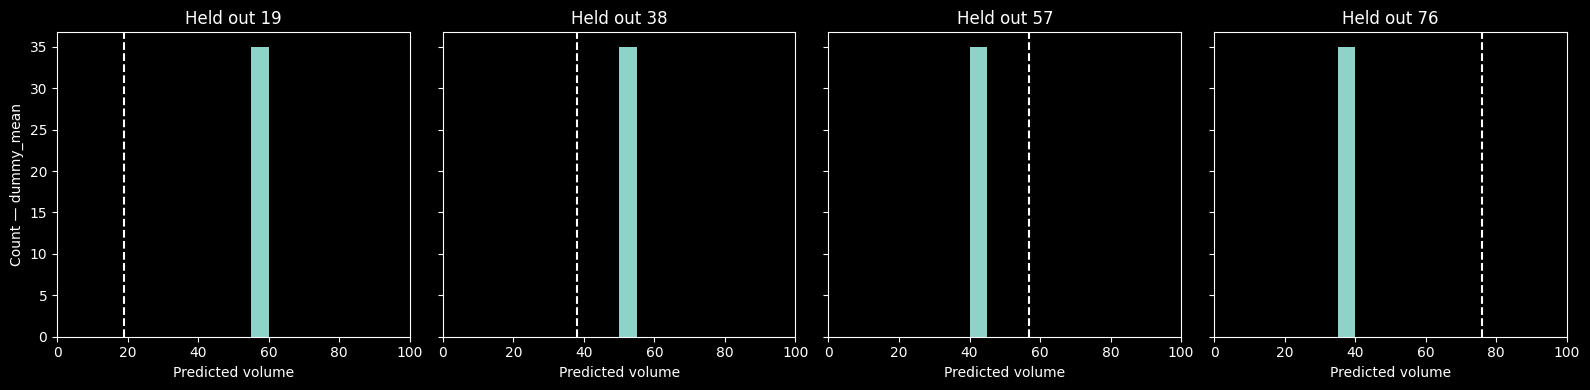

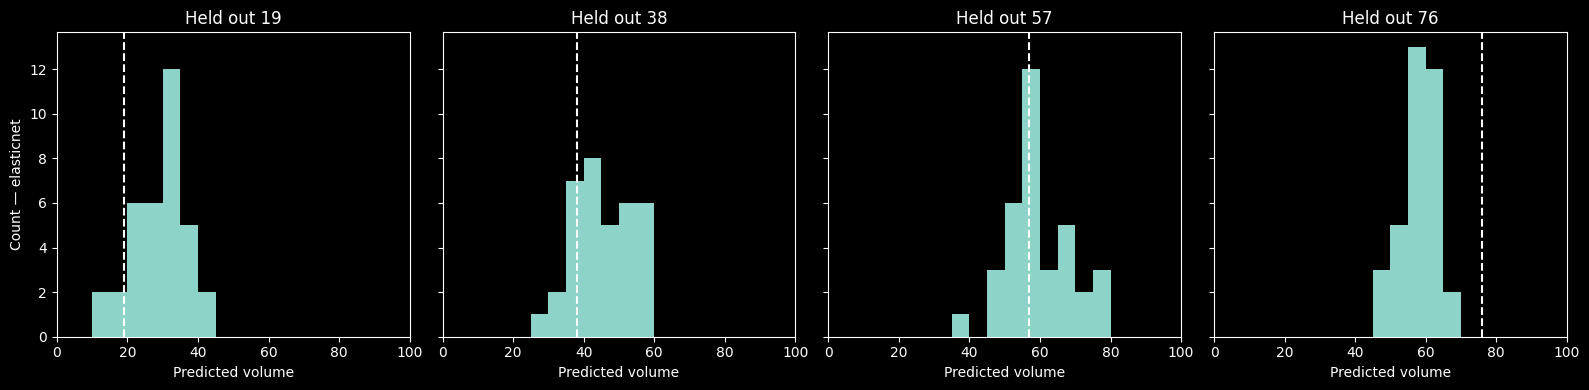

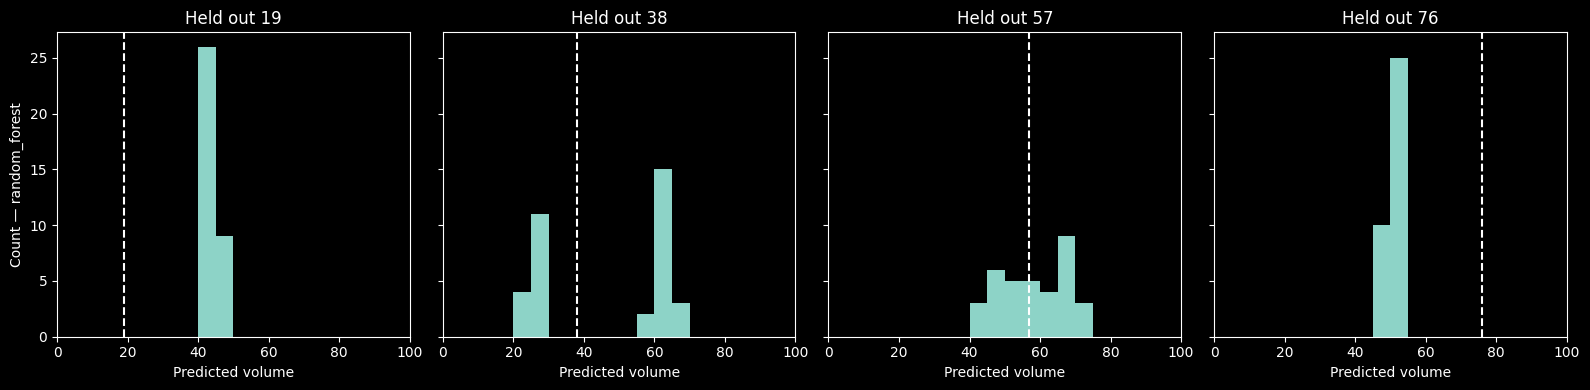

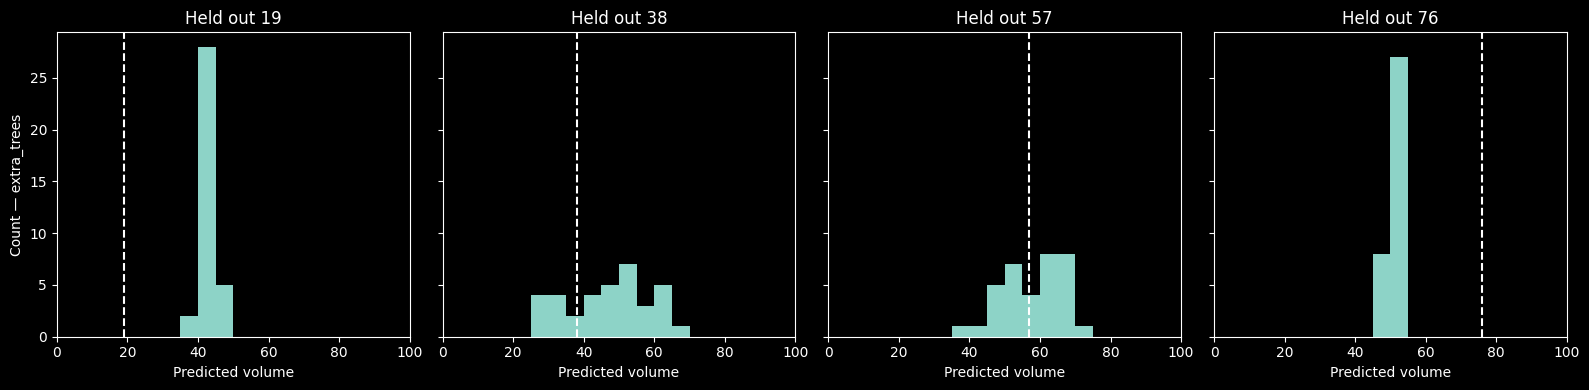

In [22]:
print("Predicted volumes on the held-out sets, for each model:")

for name, model in okay_models.items():
    fold_results = leave_one_volume_results[leave_one_volume_results["model"] == name].copy()
    predictions = leave_one_volume_predictions[leave_one_volume_predictions["model"] == name].copy()

    fig, axes = plt.subplots(1, len(unique_volumes), figsize=(4 * len(unique_volumes), 4), sharey=True)

    if len(unique_volumes) == 1:
        axes = [axes]

    for ax, vol in zip(axes, unique_volumes):
        subset = predictions[predictions["held_out_volume"] == vol]

        ax.hist(subset["pred_volume"], bins=20, range=(0, 100))
        ax.set_xlim(0, 100)
        ax.axvline(vol, linestyle="--")
        ax.set_title(f"Held out {int(vol)}")
        ax.set_xlabel("Predicted volume")

    axes[0].set_ylabel(f"Count — {name}")
    plt.tight_layout()
    plt.show()